In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score,f1_score,roc_curve, auc,precision_score ,classification_report,confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import torchtext
from torchtext.data.utils import get_tokenizer
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
import time
from transformers import AdamW
from transformers import get_linear_schedule_with_warmup
from transformers import BertModel
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import random_split

d:\miniconda3\envs\cnneopp\lib\site-packages\torchtext\data\__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)


In [2]:
data=pd.read_excel('../training_data/training_data.xlsx')
data['HLA type']=data['HLA type'].str.replace('*','')
data['HLA type']=data['HLA type'].str.replace(' ','')
data['HLA type']=data['HLA type'].str.replace('\xa0','')
data.head()

,HLA type,Mutated Peptide,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,Feature 11,label
0,HLA-A02:05,RLFPGLTIKI,0.950510,0.980,0.856370,0.2242,0.7640,6.95,1.15744,2290.86,0.07190,0.759485,0.95,1
1,HLA-A01:01,FLEGNEVGKTY,0.964270,2.384,0.516560,0.2542,0.0880,-6.49,1.25634,2290.07,0.07058,0.229257,-8.59,1
2,HLA-A01:01,LSEEAILGFEY,0.959551,2.776,0.995299,0.0517,0.6204,3.96,1.27036,2257.47,0.47935,1.015717,5.16,1
3,HLA-A01:01,STDVDKTAASY,0.973571,2.664,1.036654,0.0155,0.6681,-8.61,1.15713,2195.41,-0.12867,1.230159,-2.51,1
4,HLA-A01:01,FSEDTTDKGIY,0.776510,2.470,0.910460,0.0181,0.2870,-11.05,1.27528,2294.10,0.05538,0.538690,-8.85,1


In [3]:
def trans_Mutated(x):
  x=x+'X'*(11-len(x))
  return x

data['M']=data['Mutated Peptide'].apply(trans_Mutated)
data.head()

,HLA type,Mutated Peptide,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,Feature 11,label,M
0,HLA-A02:05,RLFPGLTIKI,0.950510,0.980,0.856370,0.2242,0.7640,6.95,1.15744,2290.86,0.07190,0.759485,0.95,1,RLFPGLTIKIX
1,HLA-A01:01,FLEGNEVGKTY,0.964270,2.384,0.516560,0.2542,0.0880,-6.49,1.25634,2290.07,0.07058,0.229257,-8.59,1,FLEGNEVGKTY
2,HLA-A01:01,LSEEAILGFEY,0.959551,2.776,0.995299,0.0517,0.6204,3.96,1.27036,2257.47,0.47935,1.015717,5.16,1,LSEEAILGFEY
3,HLA-A01:01,STDVDKTAASY,0.973571,2.664,1.036654,0.0155,0.6681,-8.61,1.15713,2195.41,-0.12867,1.230159,-2.51,1,STDVDKTAASY
4,HLA-A01:01,FSEDTTDKGIY,0.776510,2.470,0.910460,0.0181,0.2870,-11.05,1.27528,2294.10,0.05538,0.538690,-8.85,1,FSEDTTDKGIY


In [4]:
def getKmers(sequence, size):
  a,b=sequence['M'],sequence['HLA type']
  a=b+a
  a=[a[x:x+size].lower() for x in range(len(a) - size + 1)]
  return ' '.join(a)

data['trans']=data.apply(lambda row:getKmers(row, 4),axis=1)
data.head()

,HLA type,Mutated Peptide,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,Feature 11,label,M,trans
0,HLA-A02:05,RLFPGLTIKI,0.950510,0.980,0.856370,0.2242,0.7640,6.95,1.15744,2290.86,0.07190,0.759485,0.95,1,RLFPGLTIKIX,hla- la-a a-a0 -a02 a02: 02:0 2:05 :05r 05rl 5...
1,HLA-A01:01,FLEGNEVGKTY,0.964270,2.384,0.516560,0.2542,0.0880,-6.49,1.25634,2290.07,0.07058,0.229257,-8.59,1,FLEGNEVGKTY,hla- la-a a-a0 -a01 a01: 01:0 1:01 :01f 01fl 1...
2,HLA-A01:01,LSEEAILGFEY,0.959551,2.776,0.995299,0.0517,0.6204,3.96,1.27036,2257.47,0.47935,1.015717,5.16,1,LSEEAILGFEY,hla- la-a a-a0 -a01 a01: 01:0 1:01 :01l 01ls 1...
3,HLA-A01:01,STDVDKTAASY,0.973571,2.664,1.036654,0.0155,0.6681,-8.61,1.15713,2195.41,-0.12867,1.230159,-2.51,1,STDVDKTAASY,hla- la-a a-a0 -a01 a01: 01:0 1:01 :01s 01st 1...
4,HLA-A01:01,FSEDTTDKGIY,0.776510,2.470,0.910460,0.0181,0.2870,-11.05,1.27528,2294.10,0.05538,0.538690,-8.85,1,FSEDTTDKGIY,hla- la-a a-a0 -a01 a01: 01:0 1:01 :01f 01fs 1...


In [5]:
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the BioBERT tokenizer and model
tokenizer = AutoTokenizer.from_pretrained('dmis-lab/biobert-base-cased-v1.1')
biobert_model = AutoModel.from_pretrained('dmis-lab/biobert-base-cased-v1.1').to(device)
biobert_model.eval()
#Tokenize the text data and get BioBERT embeddings
input_ids = []
attention_masks = []

for text in data['trans']:
    encoded = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=64,
        padding='max_length',
        return_tensors='pt',
        truncation=True
    )
    input_ids.append(encoded['input_ids'])
    attention_masks.append(encoded['attention_mask'])

input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)

#Convert the BioBERT embeddings to features
with torch.no_grad():
    outputs = biobert_model(input_ids.to(device), attention_mask=attention_masks.to(device))
    features = outputs.last_hidden_state

#Convert the labels to PyTorch tensors
labels = torch.tensor(data['label'].values, dtype=torch.long)

#Create a custom dataset
class TextClassificationDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

# Split the data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)


train_dataset = TextClassificationDataset(X_train, y_train)
val_dataset = TextClassificationDataset(X_val, y_val)
test_dataset = TextClassificationDataset(X_test, y_test)


batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#Create the CNN model for text classification using BERT embeddings
class TextCNN(nn.Module):
    def __init__(self, input_size, num_filters, filter_sizes, output_size, dropout):
        super(TextCNN, self).__init__()
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, (fs, input_size)) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), output_size)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = [F.relu(conv(x)).squeeze(3) for conv in self.convs]
        x = [F.max_pool1d(conv, conv.size(2)).squeeze(2) for conv in x]
        x = torch.cat(x, dim=1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Define empty lists to store training and validation metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

#Define the training loop for the CNN model
def train_cnn(model, train_loader, val_loader, train_losses, val_losses, train_accuracies, val_accuracies, num_epochs=19, learning_rate=0.0001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0
        total_train_correct = 0
        total_train_samples = 0
        for batch in train_loader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train_samples += targets.size(0)
            total_train_correct += (predicted == targets).sum().item()

            loss.backward()
            optimizer.step()

        avg_train_loss = total_train_loss / len(train_loader)
        train_accuracy = 100 * total_train_correct / total_train_samples
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%')

        model.eval()
        total_val_correct = 0
        total_val_samples = 0
        total_val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                inputs, targets = batch
                inputs, targets = inputs.to(device), targets.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, targets)
                total_val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val_samples += targets.size(0)
                total_val_correct += (predicted == targets).sum().item()

        val_accuracy = 100 * total_val_correct / total_val_samples
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch + 1}/{num_epochs}], Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')


input_size = features.shape[2]
num_filters = 120
filter_sizes = [3, 4, 5]
output_size = 2
dropout = 0.2

model = TextCNN(input_size, num_filters, filter_sizes, output_size, dropout)

num_epochs = 19
learning_rate = 0.0001

# Train the CNN model
train_cnn(model, train_loader, val_loader, train_losses, val_losses, train_accuracies, val_accuracies, num_epochs=num_epochs, learning_rate=learning_rate)

# Save the trained model
torch.save(model.state_dict(), 'CNN_BioBERT.pth')

Epoch [1/19], Loss: 0.5938, Accuracy: 69.94%
Epoch [1/19], Validation Loss: 0.5362, Validation Accuracy: 73.75%
Epoch [2/19], Loss: 0.5038, Accuracy: 76.83%
Epoch [2/19], Validation Loss: 0.5206, Validation Accuracy: 75.42%
Epoch [3/19], Loss: 0.4880, Accuracy: 79.23%
Epoch [3/19], Validation Loss: 0.5262, Validation Accuracy: 73.75%
Epoch [4/19], Loss: 0.4529, Accuracy: 81.21%
Epoch [4/19], Validation Loss: 0.5119, Validation Accuracy: 76.25%
Epoch [5/19], Loss: 0.4354, Accuracy: 81.32%
Epoch [5/19], Validation Loss: 0.5014, Validation Accuracy: 75.42%
Epoch [6/19], Loss: 0.4108, Accuracy: 82.67%
Epoch [6/19], Validation Loss: 0.5178, Validation Accuracy: 74.58%
Epoch [7/19], Loss: 0.3952, Accuracy: 84.24%
Epoch [7/19], Validation Loss: 0.5100, Validation Accuracy: 74.17%
Epoch [8/19], Loss: 0.3790, Accuracy: 84.45%
Epoch [8/19], Validation Loss: 0.4921, Validation Accuracy: 75.00%
Epoch [9/19], Loss: 0.3596, Accuracy: 85.91%
Epoch [9/19], Validation Loss: 0.4961, Validation Accuracy:

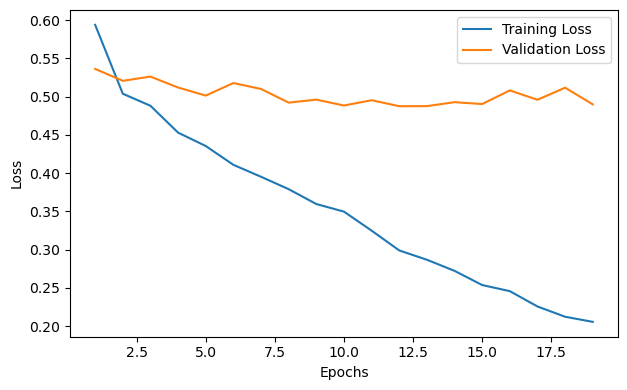

In [6]:
# Plot the training and validation loss curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

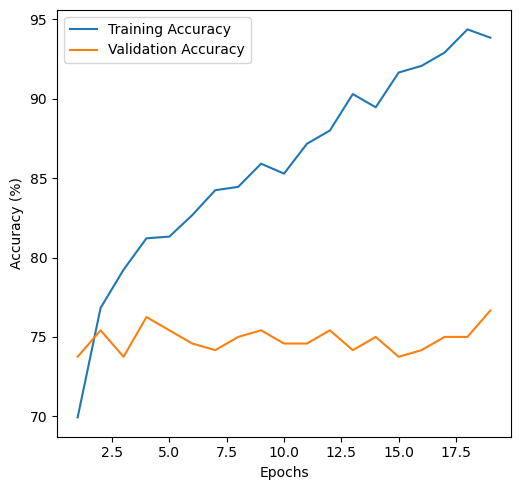

In [7]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

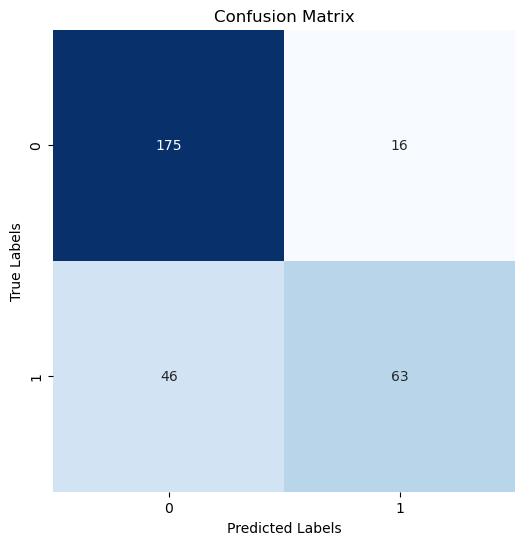

Classification Report:
               precision    recall  f1-score   support

     Class 0       0.79      0.92      0.85       191
     Class 1       0.80      0.58      0.67       109

    accuracy                           0.79       300
   macro avg       0.79      0.75      0.76       300
weighted avg       0.79      0.79      0.78       300

AUC : 0.8045
Overall Precision: 0.7947
Overall Recall: 0.7471
Overall F1-score: 0.7599


In [8]:
def evaluate(model, test_loader):
  model.eval()
  test_labels = []
  test_predictions = []
  proba=[]
  with torch.no_grad():
      for inputs, targets in test_loader:
          outputs = model(inputs)
          test_labels+=targets.tolist()
          _, predicted = torch.max(outputs, 1)
          test_predictions.extend(predicted.tolist())
          proba.append(outputs)
  # Convert predictions to a torch tensor
  test_predictions = torch.tensor(test_predictions, dtype=torch.long)

  # Calculate the confusion matrix
  cm = confusion_matrix(test_labels, test_predictions)

  # Plot the confusion matrix
  plt.figure(figsize=(6, 6))
  sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', cbar=False, square=True)
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.title('Confusion Matrix')
  plt.show()

  # Output the classification report
  target_names = ['Class 0', 'Class 1']
  classification_rep = classification_report(test_labels, test_predictions, target_names=target_names)
  print('Classification Report:\n', classification_rep)

  proba=torch.cat(proba,dim=0).cpu().numpy()
  auc_value = roc_auc_score(test_labels, proba[:,1])

  print(f'AUC : {auc_value:.4f}')

  precision = precision_score(test_labels, test_predictions, average='macro')
  recall = recall_score(test_labels, test_predictions, average='macro')
  f1 = f1_score(test_labels, test_predictions, average='macro')

  print(f'Overall Precision: {precision:.4f}')
  print(f'Overall Recall: {recall:.4f}')
  print(f'Overall F1-score: {f1:.4f}')

evaluate(model, test_loader)